In [1]:
import numpy as np
import pandas as pd
import zarr
import torch
import math
from datetime import date, datetime, timedelta
import statsmodels.api as sm
import os
import gc
import re
import shutil
import xarray as xr
import matplotlib.pyplot as plt

'for i in range(100):\n    prova = ds["ndvi_processed"].isel(pixel=i).load()\n\n    plt.plot(np.arange(prova.shape[0]), prova.values)\n    plt.title(f"Pixel {i}")\n\n    # Save plot as image named after the pixel index\n    save_path = os.path.join(OUT_DIR, f"{i}.png")\n    plt.savefig(save_path, dpi=300)\n    plt.close()\n\nprint("Saved plots for the first 100 pixels.")'

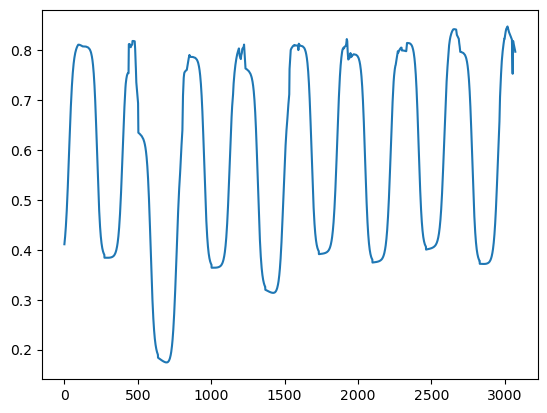

In [8]:
INPUT_DIR = "/home/francesco/data_scratch/swiss-ndvi-processing/ndvi_processed.zarr"
ds = xr.open_zarr(INPUT_DIR, chunks="auto")

prova = ds["ndvi_processed"].isel(pixel=slice(0, 1)).load()
plt.plot(np.arange(3073),prova[0].values)

OUT_DIR = "/home/francesco/data_scratch/swiss-ndvi-processing/workflow_implementation/figure/test_out_zarr"


"""for i in range(100):
    prova = ds["ndvi_processed"].isel(pixel=i).load()

    plt.plot(np.arange(prova.shape[0]), prova.values)
    plt.title(f"Pixel {i}")

    # Save plot as image named after the pixel index
    save_path = os.path.join(OUT_DIR, f"{i}.png")
    plt.savefig(save_path, dpi=300)
    plt.close()

print("Saved plots for the first 100 pixels.")"""


In [10]:
ds

<xarray.Dataset> Size: 12GB
Dimensions:         (pixel: 1000000, time: 3073)
Coordinates:
  * pixel           (pixel) float64 8MB nan 1.0 2.0 3.0 ... 1e+06 1e+06 1e+06
  * time            (time) float64 25kB 2.017e+07 2.017e+07 ... 2.025e+07
Data variables:
    ndvi_processed  (pixel, time) float32 12GB dask.array<chunksize=(5000, 3073), meta=np.ndarray>

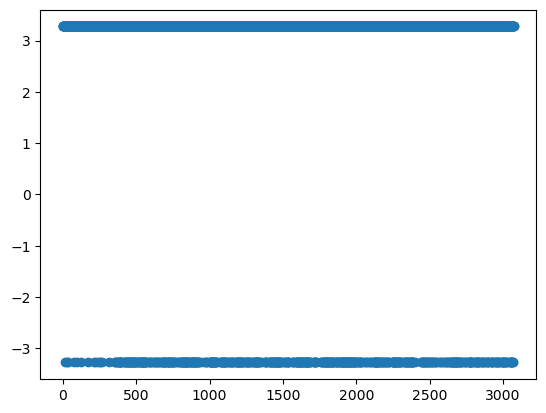

In [6]:
prova = ds["ndvi_processed"].isel(pixel=4777  ).load()
plt.scatter(np.arange(3073),prova.values)

In [35]:
for i in range(999999):
    prova = ds["ndvi_processed"].isel(pixel=i).load()

    # Check if any NDVI value > 1
    if np.any(prova.values > 1):
        print(f"Pixel {i} has NDVI values greater than 1")

Pixel 77 has NDVI values greater than 1
Pixel 533 has NDVI values greater than 1
Pixel 754 has NDVI values greater than 1
Pixel 938 has NDVI values greater than 1
Pixel 939 has NDVI values greater than 1
Pixel 941 has NDVI values greater than 1
Pixel 1051 has NDVI values greater than 1
Pixel 1052 has NDVI values greater than 1
Pixel 1053 has NDVI values greater than 1
Pixel 1054 has NDVI values greater than 1
Pixel 1442 has NDVI values greater than 1
Pixel 1446 has NDVI values greater than 1
Pixel 1574 has NDVI values greater than 1
Pixel 1575 has NDVI values greater than 1
Pixel 1576 has NDVI values greater than 1
Pixel 1577 has NDVI values greater than 1
Pixel 1578 has NDVI values greater than 1
Pixel 1922 has NDVI values greater than 1
Pixel 1938 has NDVI values greater than 1
Pixel 1950 has NDVI values greater than 1
Pixel 2088 has NDVI values greater than 1
Pixel 2089 has NDVI values greater than 1
Pixel 2090 has NDVI values greater than 1
Pixel 2432 has NDVI values greater than 1

KeyboardInterrupt: 

test of continous igestoin setup

In [2]:
INPUT_DIR = "/data_3/scratch/francesco/new_zarr.zarr"
ds = xr.open_zarr(INPUT_DIR, chunks="auto")
ds

/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:99: UserWarning: The codec `vlen-bytes` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


<xarray.Dataset> Size: 12GB
Dimensions:        (last_date_idx: 8, pixel: 1000014, param: 6, date: 3073)
Coordinates:
  * pixel          (pixel) int64 8MB 85668616 85668617 ... 94882985 94882986
  * param          (param) object 48B 'par0' 'par1' 'par2' 'par3' 'par4' 'par5'
  * last_date_idx  (last_date_idx) int64 64B 0 1 2 3 4 5 6 7
  * date           (date) datetime64[ns] 25kB 2017-04-03 ... 2025-08-31
Data variables:
    last_dates     (last_date_idx, pixel) object 64MB dask.array<chunksize=(8, 100), meta=np.ndarray>
    params_upper   (pixel, param) float32 24MB dask.array<chunksize=(100, 6), meta=np.ndarray>
    median_ndvi    (pixel, date) int16 6GB dask.array<chunksize=(100, 365), meta=np.ndarray>
    counter        (date) int16 6kB dask.array<chunksize=(365,), meta=np.ndarray>
    params_lower   (pixel, param) float32 24MB dask.array<chunksize=(100, 6), meta=np.ndarray>
    ndvi           (pixel, date) int16 6GB dask.array<chunksize=(100, 365), meta=np.ndarray>

Spinup years

In [3]:
spinup = 365
subset = ds.isel(pixel=slice(0, 199))

for pixel in np.arange(0, 199):
    # Extract NDVI subset for this pixel
    ndvi_subset = subset["ndvi"].isel(pixel=pixel)[spinup:].load()

    # Create a boolean mask for valid NDVI values
    valid_mask = (ndvi_subset > 0) & (ndvi_subset < 10000)

    # Select the first 7 valid values (indices 0–6)
    ndvi_valid = ndvi_subset.where(valid_mask, drop=True).isel(date=slice(0, 7))

    # Extract the corresponding dates (datetime64[D])
    valid_dates = ndvi_valid["date"].values.astype("datetime64[D]")

    # Make sure we always have 8 entries by padding if needed
    full_dates = np.full(8, np.datetime64("1900-01-01", "D"))  # default filler
    full_dates[:len(valid_dates)] = valid_dates  # fill with available dates
    # Assign the 8 values into last_dates (now always length 8)
    subset["last_dates"].data[:, pixel] = full_dates


In [ ]:

def continous_ndvi(pixel,current_date,last_dates_array,first_date):

    idx_current_date = int((current_date - first_date)  / np.timedelta64(1, 'D'))
    idx_last_date =  int((last_dates_array[6] - first_date)  / np.timedelta64(1, 'D'))

    current_ndvi_value = ds["ndvi"].isel(pixel=pixel, date =idx_current_date ).load().values
    last_ndvi_value =  ds["ndvi"].isel(pixel=pixel, date =idx_last_date).load().values

    current_ndvi_value = current_ndvi_value / 10000

    median_current_value =  ds["median_ndvi"].isel(pixel=pixel, date =idx_current_date).load().values
    median_last_value =  ds["median_ndvi"].isel(pixel=pixel, date =idx_last_date).load().values

    median_current_value = median_current_value / 10000.0
    median_last_value = median_last_value / 10000.0

    last_delta = last_ndvi_value - median_current_value

    # check if the current ndvi value is an obs. or not

    if (current_ndvi_value > 0) & (current_ndvi_value < 1):
             
        # check if it is a potential outlier or not
        current_delta = current_ndvi_value - median_current_value
        delta_delta = current_delta - last_delta

        print(current_delta,delta_delta)

        if ((abs(current_delta) > 0.15) & (abs(delta_delta) > 0.15)):
                 
            # the value is a potential outlier that will be checked as soon a new observation will be avaible
            last_dates_array[7] = current_date

            return last_dates_array
            
        else:
                 
            # check if a potential outlier is pending or not. 
            # If there is no potential outlier the last dates will have a placehodler value of 1900-01-01

            if last_dates_array[7] != date(1900,1,1):
                    
                potential_idx = int((last_dates_array[7] - first_date)  / np.timedelta64(1, 'D'))
                potential_ndvi_value = ds["ndvi"].isel(pixel=pixel, date = potential_idx).load().values
                potential_median_value = ds["median_ndvi"].isel(pixel=pixel, date = potential_idx).load().values

                potential_median_value = potential_median_value / 10000.0

                potential_delta = potential_ndvi_value - potential_median_value
                potential_delta_delta = potential_delta - current_delta

                if abs(potential_delta_delta) < 0.15:

                    # the potential outlier is NOT a true outlier but it is an observation
                    # since it is an obseravtion was not process before, the L1 and L2 must be done twice
                    days_diff = (current_date + np.timedelta64(1,'D') - last_dates_array[6]) / np.timedelta64(1,'D')
                    days_diff_array = np.arange(int(days_diff))
                    median_array =  ds["median_ndvi"].isel(pixel=pixel)[idx_last_date:].load().values

                    median_array = median_array/ 10000.0

                    idx_to_interpolate = np.concatenate(last_dates_array[6],last_dates_array[7],current_date)
                    delta_to_interpolate = np.concatenate(last_delta,potential_delta,current_delta)

                    interpolation = np.interp(days_diff_array,idx_to_interpolate,delta_to_interpolate)
                    L1_interpolated = median_array + interpolation
                    # write it back to ndvi array

                    # load the past 6 values to perform the smoothing (since we already loaded the last value)
                    idx_last_date_arr = int((last_dates_array[:6] - first_date)  / np.timedelta64(1, 'D'))
                    last_ndvi_arr = ds["ndvi"].isel(pixel=pixel, date = idx_last_date_arr).load().values
                    last_median_arr =  ds["median_ndvi"].isel(pixel=pixel, date = idx_last_date_arr).load().values

                    last_median_arr = last_median_arr / 10000.0

                    last_delta_arr = last_ndvi_arr - last_median_arr

                    # concatenate the apst value with last delta and current delta
                        
                    delta_to_smooth = np.concatenate(last_delta_arr, last_delta,potential_delta,current_delta)
                    idx = np.arange(1,9) # having the potential outlier as obs gives one more value
                    loess =  sm.nonparametric.lowess(delta_to_smooth, idx, frac= 1, it=3, return_sorted=False)

                    # the smoothed value to write are the third and FIFTH values instead of fourth (since we have an extra value)
                    days_diff = (last_dates_array[4] + np.timedelta64(1,'D') - last_dates_array[2]) / np.timedelta64(1,'D')
                    idx_to_smooth = np.arange(int(days_diff))

                    median_array_to_smooth =  ds["median_ndvi"].isel(pixel=pixel, date = idx_to_smooth)

                    median_array_to_smooth = median_array_to_smooth / 10000.0
                    idx_to_interp = int(((np.concatenate(last_dates_array[2],last_dates_array[3],last_dates_array[4] + np.timedelta64(1, 'D'))) - first_date)  / np.timedelta64(1, 'D'))
                        
                    interpolated_smoothed_values = np.interp(idx_to_smooth,idx_to_interp,loess[2:5])
                    ndvi_smoothed_value = interpolated_smoothed_values + median_array_to_smooth

                    # write it back to ndvi array

                    # update last date array with the new dates as shown above, INCLUDING the potential date (at 8th position)
                    last_dates_array = np.concatenate(last_dates_array[2:],current_date,date(1900,1,1))

                    return last_dates_array 


                else:

                    # the potential outlier is a true outlier but it is an observation
                    # this block of code and the following one are identical, maybe wrap in a function in the future

                    # perform the L1 linear interpolation between current date and last date
                    days_diff = (current_date + np.timedelta64(1,'D') - last_dates_array[6]) / np.timedelta64(1,'D')
                    days_diff_array = np.arange(int(days_diff))

                    median_array =  ds["median_ndvi"].isel(pixel=pixel)[idx_last_date:].load().values
                    
                    median_array = median_array / 10000.0 

                    interpolation = np.linspace(last_delta, current_delta,num = len(median_array))
                    L1_interpolated = median_array + interpolation
                    # write it back to ndvi array


                    # load the past 6 values to perform the smoothing (since we already loaded the last value)
                    idx_last_date_arr = int((last_dates_array[:6] - first_date)  / np.timedelta64(1, 'D'))
                    last_ndvi_arr = ds["ndvi"].isel(pixel=pixel, date = idx_last_date_arr).load().values
                    last_median_arr =  ds["median_ndvi"].isel(pixel=pixel, date = idx_last_date_arr).load().values

                    last_median_arr = last_median_arr / 10000.0

                    last_delta_arr = last_ndvi_arr - last_median_arr

                    # concatenate the apst value with last delta and current delta
                        
                    delta_to_smooth = np.concatenate(last_delta_arr, last_delta,current_delta)
                    idx = np.arange(1,8) # having the potential outlier as obs gives one more value
                    loess =  sm.nonparametric.lowess(delta_to_smooth, idx, frac= 1, it=3, return_sorted=False)

                    # the smoothed value to write are the third and fourth values
                    days_diff = (last_dates_array[3] + np.timedelta64(1,'D') - last_dates_array[2]) / np.timedelta64(1,'D')
                    idx_to_smooth = np.arange(int(days_diff))

                    median_array_to_smooth =  ds["median_ndvi"].isel(pixel=pixel, date = idx_to_smooth).load().values

                    median_array_to_smooth = median_array_to_smooth / 10000.0
                        
                    interpolated_smoothed_values = np.linspace(loess[2], loess[3], num = len(idx_to_smooth))
                    ndvi_smoothed_value = interpolated_smoothed_values + median_array_to_smooth

                    # write it back to ndvi array

                    # update the last date array
                    # after an observation is met, it is not possible to have a potential outlier so it must se to the placehodler value

                    last_dates_array = np.concatenate(last_dates_array[1:7],current_date,date(1900,1,1))

                    return last_dates_array 

            else:

                # perform the L1 linear interpolation between current date and last date
                days_diff = (current_date + np.timedelta64(1,'D') - last_dates_array[6]) / np.timedelta64(1,'D')
                days_diff_array = np.arange(int(days_diff))

                median_array =  ds["median_ndvi"].isel(pixel=pixel)[idx_last_date:].load().values
                median_array = median_array / 10000.0 

                interpolation = np.linspace(last_delta, current_delta,num = len(median_array))
                L1_interpolated = median_array + interpolation
                # write it back to ndvi array
                

                # load the past 6 values to perform the smoothing (since we already loaded the last value)
                idx_last_date_arr = int((last_dates_array[:6] - first_date)  / np.timedelta64(1, 'D'))
                last_ndvi_arr = ds["ndvi"].isel(pixel=pixel, date = idx_last_date_arr).load().values
                last_median_arr =  ds["median_ndvi"].isel(pixel=pixel, date = idx_last_date_arr).load().values
                last_median_arr = last_median_arr / 10000.0 

                last_delta_arr = last_ndvi_arr - last_median_arr

                # concatenate the apst value with last delta and current delta
                    
                delta_to_smooth = np.concatenate(last_delta_arr, last_delta,current_delta)
                idx = np.arange(1,8)
                loess =  sm.nonparametric.lowess(delta_to_smooth, idx, frac= 1, it=3, return_sorted=False)

                # the smoothed value to write are the third and fourth values

                days_diff = (last_dates_array[3] + np.timedelta64(1,'D') - last_dates_array[2]) / np.timedelta64(1,'D')
                idx_to_smooth = np.arange(int(days_diff))

                median_array_to_smooth =  ds["median_ndvi"].isel(pixel=pixel, date = idx_to_smooth).load().values
                median_array_to_smooth = median_array_to_smooth / 10000.0
                interpolated_smoothed_values = np.linspace(loess[2], loess[3], num = len(idx_to_smooth))
                ndvi_smoothed_value = interpolated_smoothed_values + median_array_to_smooth

                # write it back to ndvi array
                    
                # update last date array with the new dates as shown above
                last_dates_array = np.concatenate(last_dates_array[1:7],current_date,date(1900,1,1))

                return last_dates_array 

    else:
             
        # perform the L0 estimation based on the last delta avaible
        days_diff = int((last_dates_array[6] - current_date)  / np.timedelta64(1, 'D'))

        decrease_factor = math.exp(-math.log(2) * (days_diff / 15.0))
        ndvi_estimated = median_last_value + last_delta * decrease_factor
        # write it back to ndvi array

        # here no need to update the last dates array

        return last_dates_array



In [9]:
# set initial condition
first_date = ds["date"][0].load().astype("datetime64[D]").values
first_date = np.datetime64(first_date, "D")
pixel = 1
last_dates_array = np.array(subset["last_dates"].isel(pixel=1).load().values, dtype="datetime64[D]")

# run the continous ingestion
for i in np.arange(20,100):

    current_date = np.array(ds["date"][spinup + i].load().values, dtype="datetime64[D]").item()
    last_dates_array = continous_ndvi(pixel,current_date,last_dates_array,first_date)
    last_dates_array = np.array(last_dates_array, dtype="datetime64[D]")
    print(last_dates_array)


['2018-04-22' '2018-05-25' '2018-06-14' '2018-06-16' '2018-06-19'
 '2018-06-21' '2018-06-26' '1900-01-01']
['2018-04-22' '2018-05-25' '2018-06-14' '2018-06-16' '2018-06-19'
 '2018-06-21' '2018-06-26' '1900-01-01']
['2018-04-22' '2018-05-25' '2018-06-14' '2018-06-16' '2018-06-19'
 '2018-06-21' '2018-06-26' '1900-01-01']
['2018-04-22' '2018-05-25' '2018-06-14' '2018-06-16' '2018-06-19'
 '2018-06-21' '2018-06-26' '1900-01-01']
['2018-04-22' '2018-05-25' '2018-06-14' '2018-06-16' '2018-06-19'
 '2018-06-21' '2018-06-26' '1900-01-01']
['2018-04-22' '2018-05-25' '2018-06-14' '2018-06-16' '2018-06-19'
 '2018-06-21' '2018-06-26' '1900-01-01']
['2018-04-22' '2018-05-25' '2018-06-14' '2018-06-16' '2018-06-19'
 '2018-06-21' '2018-06-26' '1900-01-01']
['2018-04-22' '2018-05-25' '2018-06-14' '2018-06-16' '2018-06-19'
 '2018-06-21' '2018-06-26' '1900-01-01']
['2018-04-22' '2018-05-25' '2018-06-14' '2018-06-16' '2018-06-19'
 '2018-06-21' '2018-06-26' '1900-01-01']
['2018-04-22' '2018-05-25' '2018-06-1

ValueError: dimensions () must have the same length as the number of data dimensions, ndim=1